# ARES 2023-68A — BR Tranche Loss Monte Carlo

- Goal: distribution of **BR-tranche losses** under correlated defaults.
- Theme: **correlation / tail risk** → `rho` is the swept headline parameter.

**Model / assumptions**
- Defaults: **one-factor Gaussian copula** (single systematic factor `M`).
- PD: per-loan **tenor-adjusted cumulative PD** from the derived tape.
- LGD: recovery drawn from a **Beta** centered on `1 − LGD`; optional
  recovery-default dependence (worse recoveries in bad states) as a toggle.
- BR: **attach/detach approximation** of losses — *not* the full Section 11.1
  waterfall (simplification).
- Prepayment (CPR): secondary; optional per-loan prepay-survival haircut (toggle).
- `rho` range 0.05–0.40 (base 0.20); source = swept sensitivity, not calibrated.

## Setup

In [ ]:
import os, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
warnings.filterwarnings('ignore')

SEED = 42
N_PATHS = 50_000
CHUNK   = 5_000                      # paths per vectorized batch
RHO_GRID = [0.05, 0.10, 0.20, 0.30, 0.40] # correlation
BASE_RHO = 0.20

# toggles
APPLY_CPR   = False   # True -> scale at-risk balance by (1-CPR)^tenor
RD_DEP      = False   # True -> recoveries worse when systematic factor M is low
CPR         = 0.032   # realized estimate ~3.2% from cpr_calculation.ipynb, N
                      # only used if APPLY_CPR=True; base run leaves prepayment off
K_REC       = 20      # Beta concentration (higher = tighter recovery dispersion)
RD_SLOPE    = 0.05    # recovery-default sensitivity (only if RD_DEP)
np.random.seed(SEED)

## Load collateral (derived tape)

In [2]:
DATA_DERIVED = next(p for p in ['output/lld_ares_2023_derived.csv',
                                '../output/lld_ares_2023_derived.csv'] if os.path.exists(p))
df = pd.read_csv(DATA_DERIVED)

# fill 2 blank LGDs (already-defaulted 'D' names, no S&P recovery) with pool mean
df['LGD'] = df['LGD'].fillna(df['LGD'].mean())

balance = df['Current Balance'].to_numpy(float)               # $ per loan
pd_cum  = df['PD'].to_numpy(float).clip(1e-6, 1.0)            # tenor-adj cumulative PD
lgd     = df['LGD'].to_numpy(float).clip(0.01, 0.99)          # 1 - S&P recovery
tenor   = df['pd_years_to_horizon'].to_numpy(float)
rec_mean = 1.0 - lgd                                          # recovery mean per loan
L = len(df)
pool_par = balance.sum()
print(f'loans={L}  pool_par=${pool_par:,.0f}  mean PD={pd_cum.mean():.3f}  mean LGD={lgd.mean():.3f}')
print(f'expected pool loss (analytic) = {(pd_cum*balance*lgd).sum()/pool_par:.3%} of par')

loans=415  pool_par=$492,060,794  mean PD=0.142  mean LGD=0.608
expected pool loss (analytic) = 9.372% of par


## Tranche stack → BR attach / detach

In [3]:
mv = pd.read_excel(next(p for p in ['../../data/ARES_2023_68A/market_value_overview_ares_2023.xlsx',
                                    '../data/ARES_2023_68A/market_value_overview_ares_2023.xlsx']
                        if os.path.exists(p)), header=0)
mv['curr'] = mv['Curr(000)'].astype(float) * 1_000           # $ per class
print(mv[['Class','Curr(000)','% Sub']].to_string(index=False))

# attach = subordination below BR (all junior classes) / collateral par
br_i   = mv.index[mv['Class'] == 'BR'][0]
attach = mv.loc[br_i+1:, 'curr'].sum() / pool_par            # classes junior to BR
detach = attach + mv.loc[br_i, 'curr'] / pool_par            # + BR thickness
print(f'\nBR attach = {attach:.3f}   detach = {detach:.3f}   thickness = {detach-attach:.3f}')

Class  Curr(000) % Sub
  A1R     307500 38.6%
  A2R      20000 34.6%
   BR      52500 24.1%
   CR      30000 18.1%
  D1R      27500 12.6%
  D2R       7500 11.1%
   ER      15000  8.1%
    F        500  8.0%
  SUB      35900  0.0%

BR attach = 0.237   detach = 0.343   thickness = 0.107


## Simulation — one-factor Gaussian copula

- Per path: one factor `M`; per loan idiosyncratic `Z`.
- Latent `A = √rho·M + √(1−rho)·Z`; loan defaults if `A < Φ⁻¹(PD)`.
- Vectorized over (paths × loans) in chunks; same seed per rho → paired draws.

In [ ]:
thr  = norm.ppf(pd_cum)                                       # default thresholds
surv = (1 - CPR) ** tenor                                     # prepay-survival per loan

""" Generate 50k possible futures
Runs one factor copula and returns two arrays:
 br   = array of BR losses (0-1) per path
 pool = array of pool losses per path """
def simulate(rho, n_paths=N_PATHS, chunk=CHUNK, apply_cpr=APPLY_CPR, rd_dep=RD_DEP):
    rng = np.random.default_rng(SEED)                        # reset -> paired across rho
    a, b = np.sqrt(rho), np.sqrt(1 - rho)
    expo = balance * (surv if apply_cpr else 1.0)           # at-risk $ per loan
    br = np.empty(n_paths); pool = np.empty(n_paths)
    for s in range(0, n_paths, chunk):
        m = min(chunk, n_paths - s)
        M = rng.standard_normal(m)
        Z = rng.standard_normal((m, L))
        default = (a * M[:, None] + b * Z) < thr[None, :]    # each loan defaulted? (True/False)
        mu = rec_mean[None, :] + (RD_SLOPE * M[:, None] if rd_dep else 0.0)
        mu = np.clip(mu, 0.01, 0.99)
        rec = rng.beta(mu * K_REC, (1 - mu) * K_REC)         # recovery draw (m, L)
        loss = (default * expo[None, :] * (1 - rec)).sum(1) / pool_par
        pool[s:s+m] = loss
        br[s:s+m]   = np.clip((loss - attach) / (detach - attach), 0, 1)
    return br, pool

## Run rho sweep + metrics

In [ ]:
"""
Summarize the BR loss distribution:
"""

def metrics(br):
    p99 = np.percentile(br, 99)
    return dict(
        p_loss = np.mean(br > 0),
        e_loss = br.mean(),
        loss_95 = np.percentile(br, 95),
        loss_99 = p99,
        es_99  = br[br >= p99].mean() if (br >= p99).any() else 0.0,
    )

rows, br_by_rho = [], {}
for rho in RHO_GRID:
    br, pool = simulate(rho)
    br_by_rho[rho] = br
    rows.append({'rho': rho, **metrics(br)})
results = pd.DataFrame(rows)
results.columns = ['rho','P(BR loss>0)','E[BR loss]','95% loss','99% loss','ES(99%)']
results.round(5)

,rho,P(BR loss>0),E[BR loss],95% loss,99% loss,ES(99%)
0,0.05,0.00030,0.00004,0.00000,0.00000,0.00004
1,0.10,0.00576,0.00136,0.00000,0.00000,0.00136
2,0.20,0.03126,0.01190,0.00000,0.47549,0.76396
3,0.30,0.05994,0.02937,0.12146,1.00000,1.00000
4,0.40,0.08568,0.04866,0.43129,1.00000,1.00000


## Save results

In [6]:
os.makedirs('output', exist_ok=True)
OUT = 'output/br_montecarlo_results.csv'
results.to_csv(OUT, index=False)
print('wrote', os.path.abspath(OUT))
print(results.round(5).to_string(index=False))

wrote /Users/amine/Documents/Columbia/Classes/ENGIE 4700 - Summer Project/correlation_and_tail_risk_in_clo_tranches/project/notebooks/output/br_montecarlo_results.csv
 rho  P(BR loss>0)  E[BR loss]  95% loss  99% loss  ES(99%)
0.05       0.00030     0.00004   0.00000   0.00000  0.00004
0.10       0.00576     0.00136   0.00000   0.00000  0.00136
0.20       0.03126     0.01190   0.00000   0.47549  0.76396
0.30       0.05994     0.02937   0.12146   1.00000  1.00000
0.40       0.08568     0.04866   0.43129   1.00000  1.00000


## Plots

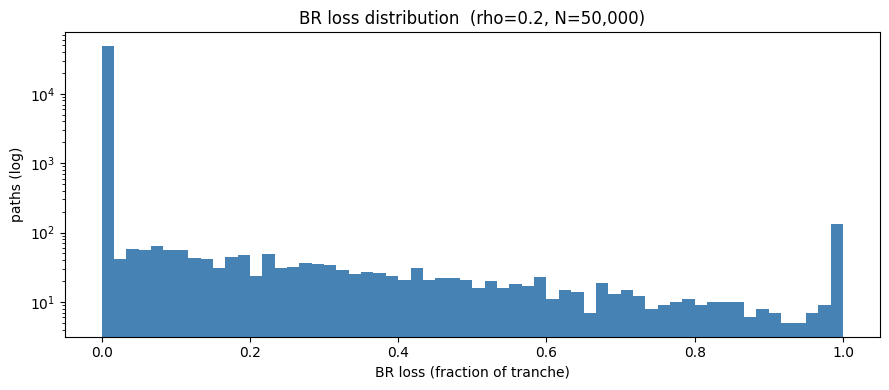

In [7]:
# (1) BR loss distribution at base rho (log y to show the tail)
br0 = br_by_rho[BASE_RHO]
plt.figure(figsize=(9,4))
plt.hist(br0, bins=60, color='steelblue')
plt.yscale('log')
plt.title(f'BR loss distribution  (rho={BASE_RHO}, N={N_PATHS:,})')
plt.xlabel('BR loss (fraction of tranche)'); plt.ylabel('paths (log)')
plt.tight_layout(); plt.show()

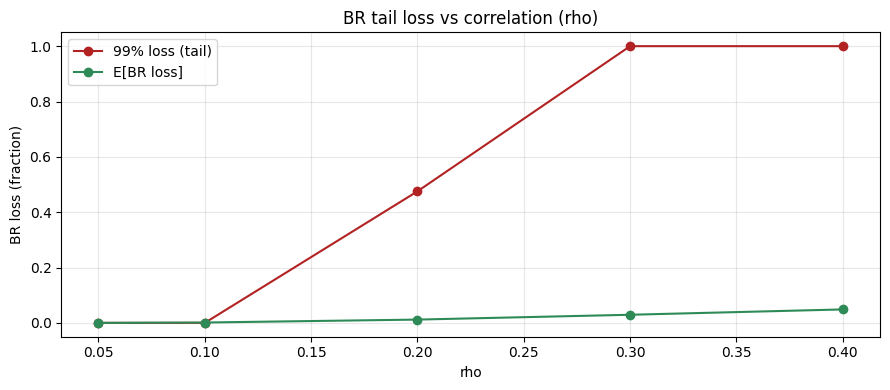

In [8]:
# (2) tail (99%) & expected loss vs rho -> headline
plt.figure(figsize=(9,4))
plt.plot(results['rho'], results['99% loss'], '-o', color='firebrick', label='99% loss (tail)')
plt.plot(results['rho'], results['E[BR loss]'], '-o', color='seagreen', label='E[BR loss]')
plt.title('BR tail loss vs correlation (rho)')
plt.xlabel('rho'); plt.ylabel('BR loss (fraction)'); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

## Findings

- Expected **pool** loss ≈ **9.4%** of par — well below BR's **23.7%** attach. So
  BR is untouched on average and is only impaired in **correlated tail** states.
- **Tail loss is the story** (rho 0.05 → 0.40):
  - `P(BR loss>0)`: **0.03% → 8.6%**
  - `99% loss`: **0 → 47% (rho 0.20) → 100%** (full wipeout at rho ≥ 0.30)
  - `ES(99%)`: **0.004% → 100%**
- `E[BR loss]` also rises (0.004% → 4.9%) but stays small — the **mean badly
  understates risk**; BR's exposure lives entirely in the tail.
- Core takeaway: **correlation barely moves the average outcome but converts a
  "safe" senior/mezz tranche into a total-wipeout candidate in the tail** — i.e.
  rho is a **tail-risk** parameter. This is the project's central result.
- Caveats: BR loss uses an **attach/detach approximation** (not the full
  Section 11.1 waterfall); rho is **swept, not calibrated**; base run excludes CPR
  (losses on current par, conservative). Toggles: `RD_DEP` (recovery-default
  dependence), `APPLY_CPR` (prepay-survival haircut).